### Implementing simple Chatbot Using LangGraph

In [2]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated, List
from langgraph.graph.message import add_messages

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [3]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64d0f9e03c', 'id': 'chatcmpl-EB2tAfXMcH9XxoTY6TTHIxfl71lsT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe7dc-8fe9-7ca2-8e25-308928cd432a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [10]:
from langchain_groq import ChatGroq
llm_grok = ChatGroq(model="qwen/qwen3.6-27b")
llm_grok.invoke("hi I am anand and like to play chess")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi I am anand and like to play chess"\n   - Key elements: \n     - Name: Anand\n     - Interest: Likes to play chess\n     - Greeting: "hi"\n\n2.  **Identify Intent/Context:**\n   - The user is introducing themselves and sharing a hobby (chess).\n   - This is a conversational opener, not a specific question or request.\n   - I should acknowledge the greeting, use their name, acknowledge their interest in chess, and engage them further (ask about their skill level, favorite openings, how they play, etc.).\n\n3.  **Formulate Response Strategy:**\n   - Greet back warmly\n   - Acknowledge their name and interest\n   - Ask an open-ended question to keep the conversation going\n   - Keep it friendly and chess-related\n   - Optionally offer help/resources if they want\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Anand! Nice to meet you. Chess is a fantastic game—there\'s always 

In [11]:
def superbot(state: State):
    return {"messages": [llm_grok.invoke(state['messages'])]}

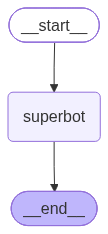

In [ ]:
graph = StateGraph(State)
## node
graph.add_node("superbot", superbot)

## Edges
graph.add_edge(START, "superbot")

graph.add_edge("superbot", END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [14]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Anand And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Anand And I like cricket', additional_kwargs={}, response_metadata={}, id='4ad8e105-ab32-4e4d-83c0-1e96b346b3bb'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User: "Hi,My name is Anand And I like cricket"\n   - Key information: \n     - Name: Anand\n     - Interest: Cricket\n   - Tone: Friendly, casual introduction\n\n2.  **Identify Core Requirements:**\n   - Acknowledge the greeting\n   - Use the user\'s name (Anand)\n   - Acknowledge their interest (cricket)\n   - Respond in a friendly, engaging manner\n   - Optionally ask a follow-up question to keep the conversation going\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Anand! Nice to meet you. Cricket\'s such a fantastic sport—do you follow a particular team, or are you more into playing it yourself? I\'d love to hear what you enjoy most about it!\n\n4.  **Check Against Requirements:**\n   - Greets back? Yes\n   - Uses name?

#### Streaming The responses

In [17]:
for event in graph_builder.stream({"messages":"Hello My name is Anand"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Anand', additional_kwargs={}, response_metadata={}, id='7b9450bd-e89c-4895-a970-79b21a17f6fb')]}
{'messages': [HumanMessage(content='Hello My name is Anand', additional_kwargs={}, response_metadata={}, id='7b9450bd-e89c-4895-a970-79b21a17f6fb'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello My name is Anand"\n   - This is a simple greeting and introduction.\n   - Key information: Name = Anand\n\n2.  **Identify Intent:**\n   - The user is introducing themselves.\n   - Expected response: Acknowledge the greeting, use their name, and offer assistance.\n\n3.  **Determine Response Guidelines:**\n   - Be polite and friendly\n   - Use the name provided\n   - Keep it concise\n   - Ask how I can help\n   - Maintain a professional yet warm tone\n\n4.  **Draft Response (Mental):**\n   Hello Anand! Nice to meet you. How can I assist you today?\n\n5.  **Refine Response:**\n   - Ch